**DEPARTMENT OF COMPUTER SCIENCE**
Submitted By:Neha Sarfaraz Khan
Submitted To:Maam Zeenat Zulfiqar
Course:Artificial Intelligence
Registration No:FA24-BCS-048
Date of Submission:25-April-2026

**Introduction:**
This assignment focuses on implementing Breadth First Search (BFS) and Depth First Search (DFS) algorithms. The objective is to understand graph traversal, performance comparison, and shortest path finding using BFS.

In [14]:
from collections import deque
import random
import time
import pandas as pd
import matplotlib.pyplot as plt

**Task 1: BFS and DFS Traversal**

In this task, a simple graph was created and both BFS and DFS algorithms were implemented to traverse the graph.


In [15]:
# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# BFS
def bfs(graph, start):
    visited = []
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            queue.extend(graph[node])
    return visited

# DFS
def dfs(graph, start):
    visited = []
    stack = [start]

    while stack:
        node = stack.pop()
        if node not in visited:
            visited.append(node)
            stack.extend(graph[node])
    return visited

print("BFS Traversal:", bfs(graph, 'A'))
print("DFS Traversal:", dfs(graph, 'A'))

BFS Traversal: ['A', 'B', 'C', 'D', 'E', 'F']
DFS Traversal: ['A', 'C', 'F', 'B', 'E', 'D']


**Task 2: BFS vs DFS Performance**

Different dataset sizes were generated and BFS and DFS execution times were measured.

**Steps:**
- Random datasets generated
- BFS and DFS applied
- Execution time recorded
- Results stored in DataFrame
- Graph plotted


      Size  BFS Time  DFS Time
0     1000  0.000343  0.000201
1    40000  0.019363  0.007150
2    80000  0.047296  0.016172
3   200000  0.106087  0.076575
4  1000000  0.588109  0.590886


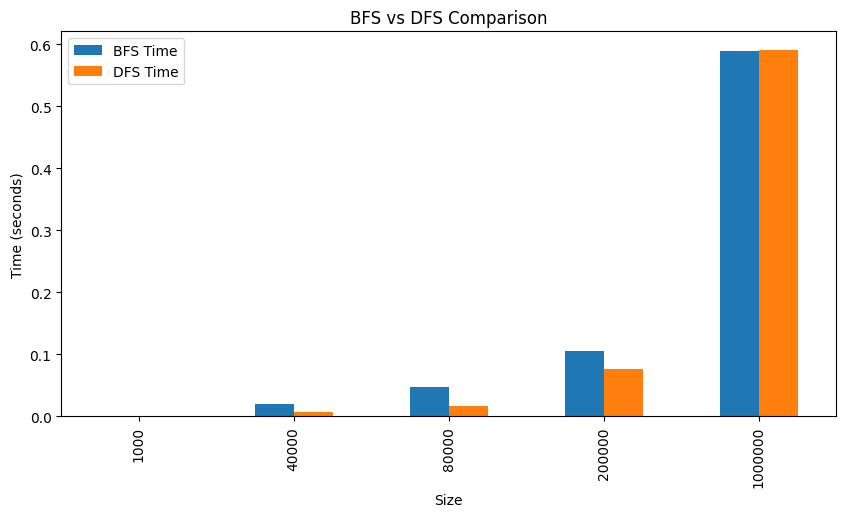

In [16]:
# sizes
sizes = [1000, 40000, 80000, 200000, 1000000]

datasets = []
results = []

# random datasets
for n in sizes:
    arr = list(range(n))
    random.shuffle(arr)
    datasets.append(arr)

# BFS
def bfs(arr, goal):
    queue = deque([0])
    visited = set()

    while queue:
        i = queue.popleft()

        if arr[i] == goal:
            return True

        if i not in visited:
            visited.add(i)

            left = 2*i + 1
            right = 2*i + 2

            if left < len(arr):
                queue.append(left)
            if right < len(arr):
                queue.append(right)

    return False

# DFS
def dfs(arr, goal):
    stack = [0]
    visited = set()

    while stack:
        i = stack.pop()

        if arr[i] == goal:
            return True

        if i not in visited:
            visited.add(i)

            left = 2*i + 1
            right = 2*i + 2

            if right < len(arr):
                stack.append(right)
            if left < len(arr):
                stack.append(left)

    return False

# time comparison
for arr in datasets:
    goal = arr[len(arr)-220]

    start = time.time()
    bfs(arr, goal)
    bfs_time = time.time() - start

    start = time.time()
    dfs(arr, goal)
    dfs_time = time.time() - start

    results.append([len(arr), bfs_time, dfs_time])

# table
df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
print(df)

# graph
df.plot(x="Size", kind="bar", figsize=(10,5))
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Comparison")
plt.show()

**Task 3: Shortest Path Using BFS**

A real-life city graph was created representing Pakistan cities. BFS was used to find the shortest path from Islamabad to Karachi.

In [20]:
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

start = "Islamabad"
goal = "Multan"

def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        city = path[-1]

        if city == goal:
            return path

        if city not in visited:
            visited.add(city)

            for neighbor in graph[city]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

    return None

result = bfs_shortest_path(graph, start, goal)
print("Shortest Path:", result)

Shortest Path: ['Islamabad', 'Lahore', 'Multan']


Youtube Link:
https://youtu.be/5Z4V749u8Dw

GitHub Link:
https://github.com/Nehasarfaraz123/AI-Lab-Task-2